In [ ]:
import os
import sys
import time
import h5py
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# 临时屏蔽 PyTorch 的 mask 类型不匹配弃用提示（不影响当前结果）
import warnings
warnings.filterwarnings(
    'ignore',
    message=r'.*mismatched key_padding_mask and attn_mask.*',
    category=UserWarning,
)

# Paths
THIS_DIR = os.getcwd()
MODULE_DIR = THIS_DIR  # unmerge/unmerger_o
REPO_DIR = os.path.abspath(os.path.join(MODULE_DIR, '..', '..'))  # PracticeTagging

sys.path.insert(0, MODULE_DIR)

import tool
from model import OrderedUnmerger, TokenTagger, DualViewTagger

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# I/O
RUN_NAME = 'dr_attn+动量守恒+7d'
OUT_DIR = os.path.join(THIS_DIR, 'runs', RUN_NAME)
FIG_DIR = os.path.join(OUT_DIR, 'figs')
CKPT_DIR = os.path.join(OUT_DIR, 'ckpts')
tool.ensure_dir(FIG_DIR)
tool.ensure_dir(CKPT_DIR)

CONFIG = {
    'data_path': os.path.join(REPO_DIR, 'test.h5'),
    'n_jets': 100000,
    'max_particles': 100,
    'pack_max_particles': 100,
    # 特征开关：'4d' => (log_pt,dEta,dPhi,log_E)，'7d' => Baseline 同款 7 维 engineered features
    'feature_kind': '7d',
    'hlt_effects': {
        'pt_resolution': 0.01,
        'eta_resolution': 0.005,
        'phi_resolution': 0.005,
        'pt_threshold_offline': 0.5,
        'pt_threshold_hlt': 1.5,
        'merge_enabled': True,
        'merge_radius': 0.01,
        'efficiency_loss': 0.01,
    },
    'model': {
        'input_dim': 4,  # will be overwritten by feature_kind switch below
        'child_dim': 4,  # will be overwritten by feature_kind switch below
        'embed_dim': 128,
        'num_heads': 8,
        'num_layers_enc': 4,
        'num_layers_dec': 3,
        'ff_dim': 512,
        'dropout': 0.1,
        'k_max': 8,
        # dR-based attention（只加在 encoder 里；默认关闭，打开后 parent/reco 都会用到）
        'use_dr_attn': True,
        'dr_sigma': 0.8,
        'dr_gamma_init': 0.5,
    },
    'train_parent': {
        'batch_size': 256,
        'epochs': 50,
        'lr': 5e-4,
        'weight_decay': 1e-5,
        'warmup_epochs': 2,
        'patience': 5,
        'grad_clip': 1.0,
        'thr_parent': 0.7,
    },
    'train_reco': {
        'batch_size': 256,
        'epochs': 50,
        'lr': 3e-4,  # decoder 大 LR
        'weight_decay': 1e-5,
        'warmup_epochs': 2,  # warmup + cosine（见 tool.train_reco_teacher_forced_obj）
        'patience': 5,
        'grad_clip': 1.0,
        'huber_delta': 1.0,
        'w_reco': 1.0,
        'w_obj': 0.5,
        'obj_pos_weight': 2.0,  # 会在 Stage2 cell 里按训练集 slot 比例自动覆盖
        'thr_obj': 0.5,
        'freeze_encoder': False,  # encoder 小 LR（不冻结）
        'enc_lr_mult': 0.1,  # encoder LR = lr * enc_lr_mult
        # px/py 守恒（方案B，相对向量误差）；守恒目标是 HLT raw parent token 的 (pt,phi)
        'w_pxy': 0,
        'pxy_eps': 1e-6,
        'w_parent_aux': 0.05,  # 小权重的 parentness 辅助 loss（防 Stage2 drift）
    },
    'infer': {
        'thr_parent': 0.7,
        'thr_obj': 0.5,
        'obj_mode': 'prefix',
        'max_children_per_parent': 8,
    },
    'io': {
        'run_name': RUN_NAME,
        'out_dir': OUT_DIR,
        'fig_dir': FIG_DIR,
        'ckpt_dir': CKPT_DIR,
        'config_path': os.path.join(OUT_DIR, 'config.json'),
        'ckpt_parent': os.path.join(CKPT_DIR, 'parent.pt'),
        'ckpt_reco': os.path.join(CKPT_DIR, 'reco_obj_tf.pt'),
        # 'load_ckpt': None,
        'load_ckpt': 1,
    },
}

# 根据 feature_kind 自动设置 input_dim/child_dim
FEATURE_KIND = str(CONFIG.get('feature_kind', '4d')).lower()
if FEATURE_KIND.startswith('7'):
    CONFIG['model']['input_dim'] = 7
    CONFIG['model']['child_dim'] = 7
else:
    CONFIG['model']['input_dim'] = 4
    CONFIG['model']['child_dim'] = 4
print('Feature kind:', FEATURE_KIND, 'input_dim:', CONFIG['model']['input_dim'], 'child_dim:', CONFIG['model']['child_dim'])

tool.save_config(CONFIG, CONFIG['io']['config_path'])
print('Data path:', CONFIG['data_path'])
print('Run dir:', CONFIG['io']['out_dir'])


Device: cuda
Feature kind: 7d input_dim: 7 child_dim: 7
Data path: d:\PracticeTagging\test.h5
Run dir: d:\PracticeTagging\unmerge\unmerger_o\runs\OrderedUnmerger_obj_only


In [2]:
# Load data
n = int(CONFIG['n_jets'])
S = int(CONFIG['max_particles'])

with h5py.File(CONFIG['data_path'], 'r') as f:
    labels = f['labels'][:n].astype(np.int64)
    weights = f['weights'][:n].astype(np.float32)
    pt = f['fjet_clus_pt'][:n, :S].astype(np.float32)
    eta = f['fjet_clus_eta'][:n, :S].astype(np.float32)
    phi = f['fjet_clus_phi'][:n, :S].astype(np.float32)
    E = f['fjet_clus_E'][:n, :S].astype(np.float32)
    masks = (pt > 0).astype(np.bool_)

constituents_raw = np.stack([pt, eta, phi, E], axis=-1)
masks_raw = masks

# Labels / weights for downstream tagger
y = labels.astype(np.float32)
w = weights.astype(np.float32)

print('Raw:', constituents_raw.shape, 'mask:', masks_raw.shape)
print('y:', y.shape, 'w:', w.shape)

Raw: (100000, 100, 4) mask: (100000, 100)
y: (100000,) w: (100000,)


In [3]:
# HLT simulation + collect merged-parent samples
k_max = int(CONFIG['model']['k_max'])

hlt_raw, hlt_mask, off_mask, group_size, hlt_axis, samples, children = tool.apply_hlt_effects_collect_samples(
    constituents_raw,
    masks_raw,
    CONFIG,
    seed=seed,
    k_max=k_max,
)
print('HLT:', hlt_raw.shape, 'mask:', hlt_mask.shape)
print('Merged-parent samples:', len(samples))

# Features in HLT axis frame
feature_kind = str(CONFIG.get('feature_kind', '4d'))
hlt_feat = tool.raw_to_feats(hlt_raw, hlt_mask, hlt_axis, kind=feature_kind)

# Offline features in HLT frame (for standardization stats)
off_raw = constituents_raw.copy()
off_raw[~off_mask] = 0.0
off_feat = tool.raw_to_feats(off_raw, off_mask, hlt_axis, kind=feature_kind)

# Split jets
idx = np.arange(hlt_feat.shape[0])
train_idx, temp_idx = train_test_split(idx, test_size=0.3, random_state=seed)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=seed)
print('Split jets:', len(train_idx), len(val_idx), len(test_idx))

# Standardize using OFFLINE TRAIN token stats
feat_means, feat_stds = tool.get_stats_tokens(off_feat, off_mask, train_idx)
hlt_feat_std = tool.standardize_tokens(hlt_feat, hlt_mask, feat_means, feat_stds, clip=10.0)
off_feat_std = tool.standardize_tokens(off_feat, off_mask, feat_means, feat_stds, clip=10.0)
print('Standardization done. D=', hlt_feat_std.shape[-1])

# Parent GT
parent_gt = tool.build_parent_targets_from_group_size(hlt_mask, group_size)
pos = float(parent_gt[train_idx][hlt_mask[train_idx]].mean())
parent_pos_weight = float((1.0 - pos) / max(pos, 1e-6))
print('Parent positive rate:', pos, 'pos_weight:', parent_pos_weight)


HLT: (100000, 100, 4) mask: (100000, 100)
Merged-parent samples: 1553729
Split jets: 70000 15000 15000
Standardization done. D= 7
Parent positive rate: 0.47836413979530334 pos_weight: 1.090457701172813


In [ ]:
# Stage1: train parentness
bs_p = int(CONFIG['train_parent']['batch_size'])
train_ds = tool.JetParentDataset(train_idx, feat_hlt_std=hlt_feat_std, mask_hlt=hlt_mask, parent_gt=parent_gt)
val_ds = tool.JetParentDataset(val_idx, feat_hlt_std=hlt_feat_std, mask_hlt=hlt_mask, parent_gt=parent_gt)
train_loader = DataLoader(train_ds, batch_size=bs_p, shuffle=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=bs_p, shuffle=False)

mcfg = CONFIG['model']
model = OrderedUnmerger(
    input_dim=int(mcfg['input_dim']),
    child_dim=int(mcfg['child_dim']),
    embed_dim=int(mcfg['embed_dim']),
    num_heads=int(mcfg['num_heads']),
    num_layers_enc=int(mcfg['num_layers_enc']),
    num_layers_dec=int(mcfg['num_layers_dec']),
    ff_dim=int(mcfg['ff_dim']),
    dropout=float(mcfg['dropout']),
    k_max=int(mcfg['k_max']),
    # dR-based attention（可选，只在 encoder 里生效）
    use_dr_attn=bool(mcfg.get('use_dr_attn', False)),
    dr_sigma=float(mcfg.get('dr_sigma', 1.0)),
    dr_gamma_init=float(mcfg.get('dr_gamma_init', 1.0)),
).to(device)
print('Model params:', sum(p.numel() for p in model.parameters()) / 1e6, 'M')

pcfg = tool.TrainCfgParent(**CONFIG['train_parent'])
load_ckpt = CONFIG['io'].get('load_ckpt', None)
ckpt_parent = CONFIG['io']['ckpt_parent']

if (load_ckpt is not None) and os.path.exists(ckpt_parent):
    print('Loading Stage1 parentness ckpt:', ckpt_parent)
    tool.load_checkpoint(model, ckpt_parent, map_location=device)
    info_parent = {'best': float('nan'), 'loaded': True}
else:
    info_parent = tool.train_parentness(
        model,
        train_loader,
        val_loader,
        device,
        pcfg,
        pos_weight=float(parent_pos_weight),
        ckpt_path=ckpt_parent,
    )
print('Best val parent loss:', info_parent.get('best', float('nan')))


Model params: 1.656202 M


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


[Parent] Ep 001: train_parent=0.4475 val_parent=0.4229 prec=0.794 rec=0.823 auc=0.8804 no_imp=0


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


[Parent] Ep 002: train_parent=0.4250 val_parent=0.4266 prec=0.787 rec=0.869 auc=0.8825 no_imp=1


...

[Parent] Ep 031: train_parent=0.4006 val_parent=0.4038 prec=0.805 rec=0.825 auc=0.8919 no_imp=3


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


[Parent] Ep 032: train_parent=0.4003 val_parent=0.4050 prec=0.802 rec=0.837 auc=0.8916 no_imp=4


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


[Parent] Ep 033: train_parent=0.3998 val_parent=0.4035 prec=0.805 rec=0.828 auc=0.8924 no_imp=5
[Parent] Early stopping.
Best val parent loss: 0.40315971637176257


Parentness token-level AUC: 0.8881898707660941


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Saved figure: d:\PracticeTagging\unmerge\unmerger_o\runs\OrderedUnmerger_obj_only\figs\parentness_cm_and_roc.png


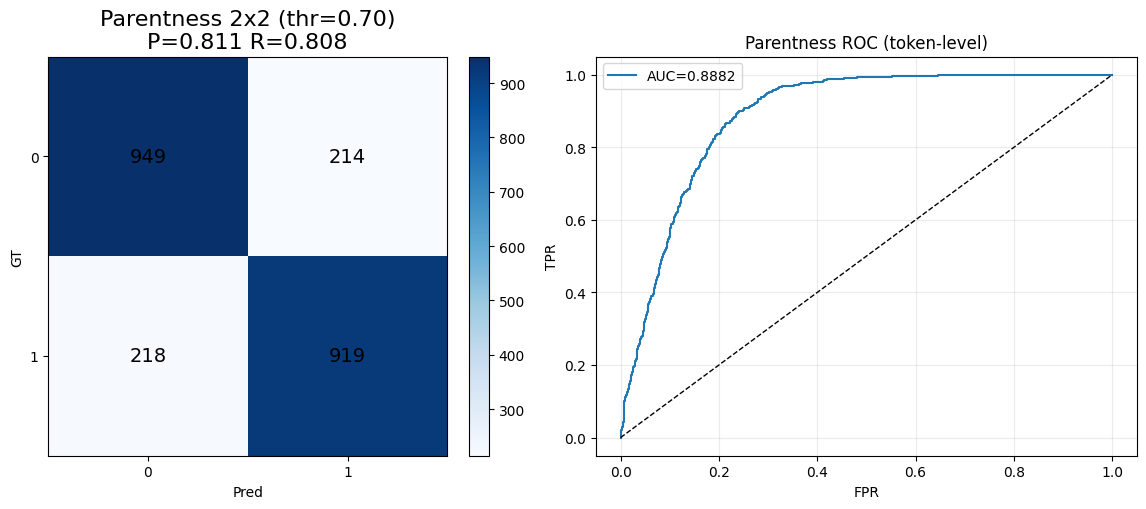

In [ ]:
# Stage1 训练后可视化：parent heatmap + ROC（放在一张图里）
from sklearn.metrics import roc_curve, roc_auc_score

model.eval()
thr_parent = float(CONFIG['train_parent']['thr_parent'])

N_plot_jets = 2042
jet_eval = val_idx[:N_plot_jets]

with torch.no_grad():
    xb = torch.tensor(hlt_feat_std[jet_eval], dtype=torch.float32, device=device)
    mb = torch.tensor(hlt_mask[jet_eval], dtype=torch.bool, device=device)
    outb = model(xb, mb, parent_idx=None)
    prob_parent = torch.sigmoid(outb.parent_logit).detach().cpu().numpy()  # [B,S]

gt_parent = parent_gt[jet_eval]  # [B,S]
mask_eval = hlt_mask[jet_eval]  # [B,S]

# token-level ROC（只在 valid token 上统计）
y_true = gt_parent[mask_eval].reshape(-1).astype(np.int32)
y_score = prob_parent[mask_eval].reshape(-1).astype(np.float64)
auc = float(roc_auc_score(y_true, y_score))
fpr, tpr, _ = roc_curve(y_true, y_score)
print('Parentness token-level AUC:', auc)

# 一张图：pred heatmap / gt heatmap / ROC
# 2x2 confusion matrix（thr_parent）
pred = (y_score > float(thr_parent)).astype(np.int32)
cm = np.zeros((2, 2), dtype=np.int64)
for gt in (0, 1):
    for pr in (0, 1):
        cm[gt, pr] = int(((y_true == gt) & (pred == pr)).sum())
P = float(cm[1, 1] / max(1, (cm[0, 1] + cm[1, 1])))
R = float(cm[1, 1] / max(1, (cm[1, 0] + cm[1, 1])))

# 一张图：2x2 heatmap + ROC
fig, ax = plt.subplots(1, 2, figsize=(12.5, 5.2))
im = ax[0].imshow(cm, origin='upper', cmap='Blues')
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, str(int(cm[i, j])), ha='center', va='center', fontsize=14)
ax[0].set_xticks([0, 1])
ax[0].set_yticks([0, 1])
ax[0].set_xticklabels(['0', '1'])
ax[0].set_yticklabels(['0', '1'])
ax[0].set_xlabel('Pred')
ax[0].set_ylabel('GT')
ax[0].set_title(f'Parentness 2x2 (thr={thr_parent:.2f})\nP={P:.3f} R={R:.3f}', fontsize=16)
plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

ax[1].plot(fpr, tpr, label=f'AUC={auc:.4f}')
ax[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
ax[1].set_title('Parentness ROC (token-level)')
ax[1].set_xlabel('FPR')
ax[1].set_ylabel('TPR')
ax[1].grid(True, alpha=0.25)
ax[1].legend()

fig.tight_layout()
fig_path = os.path.join(CONFIG['io']['fig_dir'], 'parentness_cm_and_roc.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
print('Saved figure:', fig_path)
plt.show()


In [ ]:
# Stage2: train reconstruction + objectness (teacher-forced)
sample_idx = np.arange(len(samples), dtype=np.int64)
train_s, val_s = train_test_split(sample_idx, test_size=0.2, random_state=seed)
print('Reco samples:', len(train_s), len(val_s))

# 自动计算 objectness 的 pos_weight（按训练集 slot 统计：neg/pos）
# 说明：tgt_mask=True 的 slot 视为正样本；其余 padding slot 视为负样本
k_max = int(CONFIG['model']['k_max'])
pos_slots = 0
for s in train_s.tolist():
    pos_slots += int(len(children[int(s)]))
total_slots = int(len(train_s)) * int(k_max)
neg_slots = int(total_slots - pos_slots)
pos_rate = float(pos_slots / max(1, total_slots))
obj_pos_weight = float(neg_slots / max(1, pos_slots))

CONFIG['train_reco']['obj_pos_weight'] = obj_pos_weight
print('Obj positive rate:', pos_rate, 'pos_weight:', obj_pos_weight)

bs_r = int(CONFIG['train_reco']['batch_size'])
reco_train_ds = tool.ParentRecoDataset(
    train_s,
    samples=samples,
    children=children,
    feat_hlt_std=hlt_feat_std,
    mask_hlt=hlt_mask,
    off_child_feat_std=off_feat_std,
    k_max=int(CONFIG['model']['k_max']),
    # px/py 守恒辅助 loss 用到：HLT raw parent token (pt,phi) + jet_phi
    hlt_raw=hlt_raw,
    hlt_axis=hlt_axis,
    parent_gt=parent_gt,
)
reco_val_ds = tool.ParentRecoDataset(
    val_s,
    samples=samples,
    children=children,
    feat_hlt_std=hlt_feat_std,
    mask_hlt=hlt_mask,
    off_child_feat_std=off_feat_std,
    k_max=int(CONFIG['model']['k_max']),
    hlt_raw=hlt_raw,
    hlt_axis=hlt_axis,
    parent_gt=parent_gt,
)
reco_train_loader = DataLoader(reco_train_ds, batch_size=bs_r, shuffle=True, drop_last=True)
reco_val_loader = DataLoader(reco_val_ds, batch_size=bs_r, shuffle=False)

rcfg = tool.TrainCfgRecoObj(**CONFIG['train_reco'])
load_ckpt = CONFIG['io'].get('load_ckpt', None)
ckpt_reco = CONFIG['io']['ckpt_reco']

if (load_ckpt is not None) and os.path.exists(ckpt_reco):
    print('Loading Stage2 reco ckpt:', ckpt_reco)
    tool.load_checkpoint(model, ckpt_reco, map_location=device)
    info_reco = {'best': float('nan'), 'loaded': True}
else:
    info_reco = tool.train_reco_teacher_forced_obj(
        model,
        reco_train_loader,
        reco_val_loader,
        device,
        rcfg,
        feat_means=feat_means,
        feat_stds=feat_stds,
        pos_weight_parent=float(parent_pos_weight),
        ckpt_path=ckpt_reco,
    )
print('Best val total loss:', info_reco.get('best', float('nan')))


Reco samples: 1242983 310746
Obj positive rate: 0.295166345798776 pos_weight: 2.3879201143132045


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\functional.py:6044: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


[Reco+Obj] Ep 001: train_total=0.5410 (reco=0.4067, obj=0.2270, p_aux=0.4151, pxy=0.0000) val_total=0.3167 (reco=0.2156, obj=0.1609, p_aux=0.4122, pxy=0.0000) maeL=0.361 slot_prec=0.910 slot_rec=0.939 no_imp=0
[Reco+Obj] Ep 002: train_total=0.3428 (reco=0.2408, obj=0.1626, p_aux=0.4144, pxy=0.0000) val_total=0.3179 (reco=0.2176, obj=0.1594, p_aux=0.4106, pxy=0.0000) maeL=0.320 slot_prec=0.937 slot_rec=0.927 no_imp=1
[Reco+Obj] Ep 003: train_total=0.3260 (reco=0.2252, obj=0.1604, p_aux=0.4134, pxy=0.0000) val_total=0.3274 (reco=0.2279, obj=0.1582, p_aux=0.4103, pxy=0.0000) maeL=0.354 slot_prec=0.914 slot_rec=0.939 no_imp=2
[Reco+Obj] Ep 004: train_total=0.3195 (reco=0.2190, obj=0.1596, p_aux=0.4131, pxy=0.0000) val_total=0.3080 (reco=0.2087, obj=0.1576, p_aux=0.4101, pxy=0.0000) maeL=0.319 slot_prec=0.937 slot_rec=0.928 no_imp=0
[Reco+Obj] Ep 005: train_total=0.3153 (reco=0.2152, obj=0.1590, p_aux=0.4130, pxy=0.0000) val_total=0.3105 (reco=0.2115, obj=0.1571, p_aux=0.4105, pxy=0.0000) m

In [ ]:
# Stage2 训练后可视化：8x8 热图 + jet-level sum(obj) 诊断图
model.eval()

# (0) parentness：reco 训练前后对比
# 说明：pre = 只训练完 Stage1(parentness) 的 checkpoint；post = 当前 model（训练完 Stage2 后）
from sklearn.metrics import roc_auc_score, roc_curve

thr_parent = float(CONFIG['infer']['thr_parent'])
N_plot_jets = 2042
jet_eval = val_idx[:N_plot_jets]

# 加载 pre(Stage1) checkpoint
pre_model = None
if os.path.exists(CONFIG['io']['ckpt_parent']):
    pre_model = OrderedUnmerger(
        input_dim=int(CONFIG['model']['input_dim']),
        child_dim=int(CONFIG['model']['child_dim']),
        embed_dim=int(CONFIG['model']['embed_dim']),
        num_heads=int(CONFIG['model']['num_heads']),
        num_layers_enc=int(CONFIG['model']['num_layers_enc']),
        num_layers_dec=int(CONFIG['model']['num_layers_dec']),
        ff_dim=int(CONFIG['model']['ff_dim']),
        dropout=float(CONFIG['model']['dropout']),
        k_max=int(CONFIG['model']['k_max']),
        # dR-based attention（可选）
        use_dr_attn=bool(CONFIG['model'].get('use_dr_attn', False)),
        dr_sigma=float(CONFIG['model'].get('dr_sigma', 1.0)),
        dr_gamma_init=float(CONFIG['model'].get('dr_gamma_init', 1.0)),
    ).to(device)
    tool.load_checkpoint(pre_model, CONFIG['io']['ckpt_parent'], map_location=device)
    pre_model.eval()
else:
    print('Warning: ckpt_parent not found, skip pre/post parentness comparison:', CONFIG['io']['ckpt_parent'])

with torch.no_grad():
    xb = torch.tensor(hlt_feat_std[jet_eval], dtype=torch.float32, device=device)
    mb = torch.tensor(hlt_mask[jet_eval], dtype=torch.bool, device=device)

    out_post = model(xb, mb, parent_idx=None)
    prob_post = torch.sigmoid(out_post.parent_logit).detach().cpu().numpy()  # [B,S]

    prob_pre = None
    if pre_model is not None:
        out_pre = pre_model(xb, mb, parent_idx=None)
        prob_pre = torch.sigmoid(out_pre.parent_logit).detach().cpu().numpy()  # [B,S]

gt_parent = parent_gt[jet_eval]
mask_eval = hlt_mask[jet_eval]

y_true = gt_parent[mask_eval].reshape(-1).astype(np.int32)
score_post = prob_post[mask_eval].reshape(-1).astype(np.float64)
auc_post = float(roc_auc_score(y_true, score_post))
fpr_post, tpr_post, _ = roc_curve(y_true, score_post)

if prob_pre is not None:
    score_pre = prob_pre[mask_eval].reshape(-1).astype(np.float64)
    auc_pre = float(roc_auc_score(y_true, score_pre))
    fpr_pre, tpr_pre, _ = roc_curve(y_true, score_pre)
else:
    score_pre = None
    auc_pre = float('nan')
    fpr_pre, tpr_pre = None, None


# 合并图：pre confusion / post confusion / ROC

def _cm_from_scores(scores: np.ndarray) -> tuple[np.ndarray, float, float]:
    pred = (scores > float(thr_parent)).astype(np.int32)
    cm = np.zeros((2, 2), dtype=np.int64)
    for gt in (0, 1):
        for pr in (0, 1):
            cm[gt, pr] = int(((y_true == gt) & (pred == pr)).sum())
    P = float(cm[1, 1] / max(1, (cm[0, 1] + cm[1, 1])))
    R = float(cm[1, 1] / max(1, (cm[1, 0] + cm[1, 1])))
    return cm, P, R

cm_post, P_post, R_post = _cm_from_scores(score_post)
cm_pre = None
P_pre = float('nan')
R_pre = float('nan')
if score_pre is not None:
    cm_pre, P_pre, R_pre = _cm_from_scores(score_pre)

fig, ax = plt.subplots(1, 3, figsize=(16.8, 5.2))

# pre
if cm_pre is not None:
    im0 = ax[0].imshow(cm_pre, origin='upper', cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax[0].text(j, i, str(int(cm_pre[i, j])), ha='center', va='center', fontsize=14)
    ax[0].set_title(f'Parentness pre(Stage1)\n(thr={thr_parent:.2f}) P={P_pre:.3f} R={R_pre:.3f}', fontsize=14)
    plt.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)
else:
    ax[0].axis('off')
    ax[0].set_title('Parentness pre(Stage1)\n(missing ckpt)', fontsize=14)

# post
im1 = ax[1].imshow(cm_post, origin='upper', cmap='Blues')
for i in range(2):
    for j in range(2):
        ax[1].text(j, i, str(int(cm_post[i, j])), ha='center', va='center', fontsize=14)
ax[1].set_title(f'Parentness post(Stage2)\n(thr={thr_parent:.2f}) P={P_post:.3f} R={R_post:.3f}', fontsize=14)
plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)

for a in (ax[0], ax[1]):
    a.set_xticks([0, 1]); a.set_yticks([0, 1])
    a.set_xticklabels(['0', '1']); a.set_yticklabels(['0', '1'])
    a.set_xlabel('Pred'); a.set_ylabel('GT')

# ROC
if fpr_pre is not None:
    ax[2].plot(fpr_pre, tpr_pre, label=f'pre AUC={auc_pre:.4f}')
ax[2].plot(fpr_post, tpr_post, label=f'post AUC={auc_post:.4f}')
ax[2].plot([0, 1], [0, 1], 'k--', linewidth=1)
ax[2].set_xlabel('FPR')
ax[2].set_ylabel('TPR')
ax[2].set_title('Parentness ROC (token-level) pre vs post', fontsize=14)
ax[2].grid(True, alpha=0.25)
ax[2].legend()

fig.tight_layout()
fig_path = os.path.join(CONFIG['io']['fig_dir'], 'parentness_pre_post_summary.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
print('Saved figure:', fig_path)
plt.show()

Kmax = int(CONFIG['model']['k_max'])
thr_obj = float(CONFIG['infer']['thr_obj'])

# (1) 8x8 热图：true m vs pred L（prefix+threshold），在 val parent samples 上统计
cm = np.zeros((Kmax, Kmax), dtype=np.int64)
max_samples = 200000
seen = 0

with torch.no_grad():
    for batch in reco_val_loader:
        x = batch['hlt'].to(device)
        m = batch['mask_hlt'].to(device)
        parent_idx = batch['parent_idx'].to(device)
        tgt_mask = batch['tgt_mask'].to(device)
        out = model(x, m, parent_idx=parent_idx)
        obj_prob = torch.sigmoid(out.obj_logit).detach().cpu()  # [B,K]
        L_pred = tool.prefix_lengths_from_prob(obj_prob, float(thr_obj)).cpu().numpy().astype(np.int64)
        m_true = tgt_mask.detach().cpu().sum(dim=1).numpy().astype(np.int64)

        # clip 到 0..Kmax-1（做 8x8）
        t = np.clip(m_true, 0, Kmax - 1)
        p = np.clip(L_pred, 0, Kmax - 1)
        for ti, pi in zip(t.tolist(), p.tolist()):
            cm[int(ti), int(pi)] += 1

        seen += int(x.shape[0])
        if seen >= int(max_samples):
            break

fig, ax = plt.subplots(1, 1, figsize=(6.2, 5.2))
im = ax.imshow(cm, origin='upper', cmap='Blues')
ax.set_xlabel('pred L (clipped)')
ax.set_ylabel('true m (clipped)')
ax.set_title(f'Length confusion (val parent samples)\nthr_obj={thr_obj:.2f}')
ax.set_xticks(np.arange(Kmax))
ax.set_yticks(np.arange(Kmax))
for i in range(Kmax):
    for j in range(Kmax):
        ax.text(j, i, str(int(cm[i, j])), ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig_path = os.path.join(CONFIG['io']['fig_dir'], 'obj_len_confusion_8x8.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
print('Saved figure:', fig_path)
plt.show()

# (2) Jet-level：sum(obj) true vs pred（对应之前 sum(k) 的诊断图）
N_plot_jets = 2048
jet_eval = val_idx[:N_plot_jets]
jet_set = set(int(j) for j in jet_eval.tolist())

# 收集这些 jet 的所有 GT parent samples
s_idx = [i for i, (j, p) in enumerate(samples) if int(j) in jet_set]
print('Jet-level sum(obj): eval jets=', int(len(jet_eval)), 'parent samples=', int(len(s_idx)))

from collections import defaultdict
sum_true = defaultdict(int)
sum_pred = defaultdict(int)

bs_obj = 512
all_s = np.asarray(s_idx, dtype=np.int64)
for s0 in range(0, int(all_s.size), int(bs_obj)):
    ss = all_s[s0 : s0 + int(bs_obj)]
    x_list = []
    m_list = []
    pidx_list = []
    jet_of_b = []
    true_len_b = []
    for s in ss:
        j, p = samples[int(s)]
        x_list.append(hlt_feat_std[int(j)])
        m_list.append(hlt_mask[int(j)])
        pidx_list.append(int(p))
        jet_of_b.append(int(j))
        true_len_b.append(int(len(children[int(s)])))

    xP = torch.tensor(np.stack(x_list, axis=0), dtype=torch.float32, device=device)
    mP = torch.tensor(np.stack(m_list, axis=0), dtype=torch.bool, device=device)
    pidx = torch.tensor(np.asarray(pidx_list, dtype=np.int64), dtype=torch.long, device=device)

    with torch.no_grad():
        outP = model(xP, mP, parent_idx=pidx)
        obj_prob_b = torch.sigmoid(outP.obj_logit)
        L_pred_b = tool.prefix_lengths_from_prob(obj_prob_b.detach().cpu(), float(thr_obj)).numpy().astype(np.int32)

    for j, tlen, plen in zip(jet_of_b, true_len_b, L_pred_b.tolist()):
        sum_true[int(j)] += int(tlen)
        sum_pred[int(j)] += int(plen)

jt = np.asarray(sorted(sum_true.keys()), dtype=np.int64)
true_sum = np.asarray([sum_true[int(j)] for j in jt], dtype=np.int32)
pred_sum = np.asarray([sum_pred[int(j)] for j in jt], dtype=np.int32)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hexbin(true_sum, pred_sum, gridsize=30, bins='log', mincnt=1)
ax[0].plot([true_sum.min(), true_sum.max()], [true_sum.min(), true_sum.max()], 'k--', linewidth=1)
ax[0].set_xlabel('true sum(obj_gt) per jet')
ax[0].set_ylabel('pred sum(prefix_len) per jet')
ax[0].set_title('Jet-level: pred vs true')

res = pred_sum - true_sum
ax[1].hist(res, bins=res.max() - res.min())
ax[1].set_title('Residual: pred - true')
ax[1].set_xlabel('pred - true')
ax[1].set_ylabel('jets')

ax[2].hist(true_sum, bins=40, alpha=0.6, label='true')
ax[2].hist(pred_sum, bins=40, alpha=0.6, label='pred')
ax[2].set_title('Distributions')
ax[2].set_xlabel('sum(obj) per jet')
ax[2].set_ylabel('jets')
ax[2].legend()

fig.tight_layout()
fig_path = os.path.join(CONFIG['io']['fig_dir'], 'sum_obj_jet_level.png')
plt.savefig(fig_path, dpi=160, bbox_inches='tight')
print('Saved figure:', fig_path)
plt.show()


SyntaxError: invalid syntax (2697423772.py, line 9)

In [ ]:
# Inference: build unmerged view
infer = CONFIG['infer']
t0 = time.time()
unm_raw_all, unm_mask_all, unm_feat_std_all = tool.build_unmerged_view_ordered(
    model,
    device,
    hlt_raw=hlt_raw,
    hlt_mask=hlt_mask,
    hlt_feat_std=hlt_feat_std,
    hlt_axis=hlt_axis,
    feat_means=feat_means,
    feat_stds=feat_stds,
    max_particles=int(CONFIG['pack_max_particles']),
    thr_parent=float(infer['thr_parent']),
    thr_obj=float(infer['thr_obj']),
    obj_mode=str(infer['obj_mode']),
    max_children_per_parent=int(infer['max_children_per_parent']),
)
print('Done. time=', time.time() - t0, 's')
print('UNM feat:', unm_feat_std_all.shape, 'mask:', unm_mask_all.shape)
print('Packed tokens mean=', float(unm_mask_all.sum(axis=1).mean()))


Done. time= 297.9298584461212 s
UNM feat: (50000, 100, 4) mask: (50000, 100)
Packed tokens mean= 51.56768


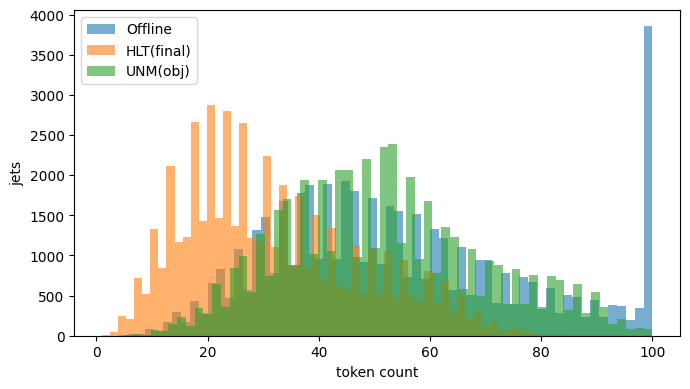

In [ ]:
# Token count comparison (offline vs HLT vs UNM)
off_counts = off_mask.sum(axis=1)
hlt_counts = hlt_mask.sum(axis=1)
unm_counts = unm_mask_all.sum(axis=1)

plt.figure(figsize=(7,4))
plt.hist(off_counts, bins=60, alpha=0.6, label='Offline')
plt.hist(hlt_counts, bins=60, alpha=0.6, label='HLT(final)')
plt.hist(unm_counts, bins=60, alpha=0.6, label='UNM(obj)')
plt.xlabel('token count')
plt.ylabel('jets')
plt.legend()
plt.tight_layout()
plt.show()


Reco panel slots: 360314 D= 4
Saved figure: d:\PracticeTagging\unmerge\unmerger_o\runs\OrderedUnmerger_obj_only\figs\reco_log_pt_panels.png


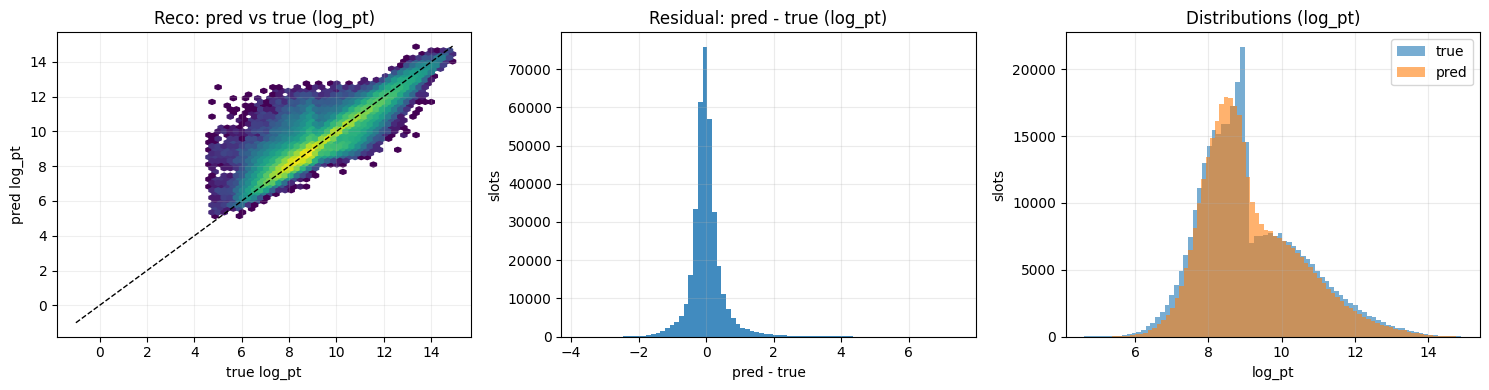

Saved figure: d:\PracticeTagging\unmerge\unmerger_o\runs\OrderedUnmerger_obj_only\figs\reco_dEta_panels.png


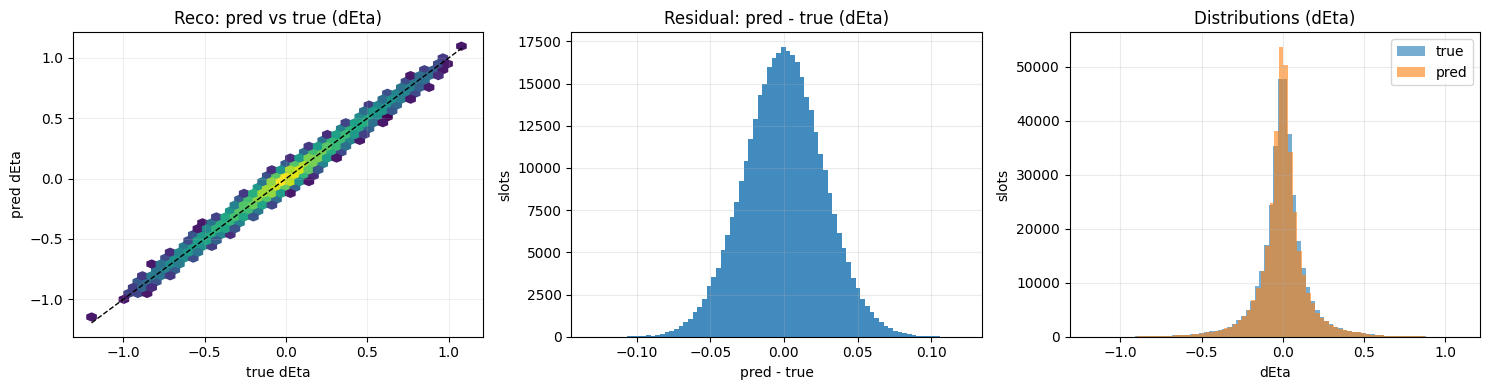

Saved figure: d:\PracticeTagging\unmerge\unmerger_o\runs\OrderedUnmerger_obj_only\figs\reco_dPhi_panels.png


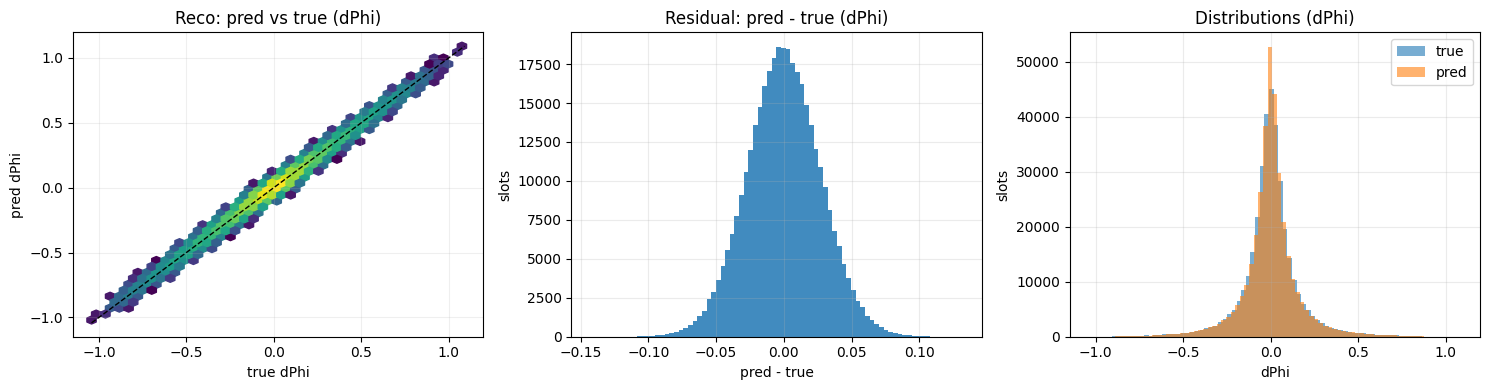

Saved figure: d:\PracticeTagging\unmerge\unmerger_o\runs\OrderedUnmerger_obj_only\figs\reco_log_E_panels.png


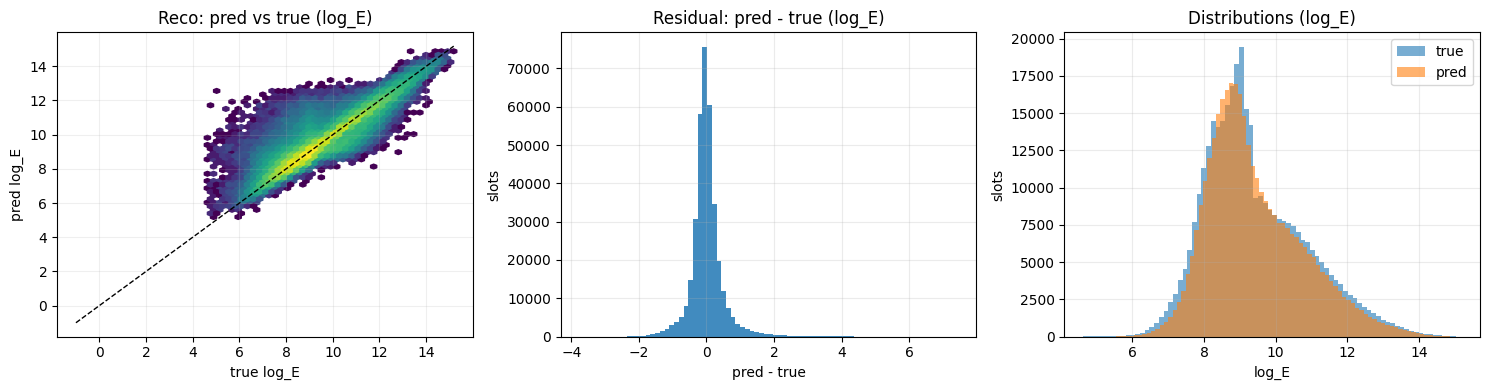

In [ ]:
# Reco feature panels: pred vs true / residual / distributions（每个 feature 一张三联图）
# 说明：这里的 pred/true 都是在“特征空间（反标准化后）”比较，只统计真实 slot（tgt_mask=True）

model.eval()
Kmax = int(CONFIG['model']['k_max'])
D_child = int(CONFIG['model']['child_dim'])

# 特征名（和 feature_kind 对齐）
if D_child == 4:
    dim_names = ['log_pt', 'dEta', 'dPhi', 'log_E']
else:
    dim_names = ['dEta', 'dPhi', 'log_pt', 'log_E', 'log_pt_over_jetpt', 'log_E_over_jetE', 'dR']
dim_names = dim_names[:D_child]

# 收集一部分 val parent samples（避免太慢）
max_parent_samples = 200000
pred_list = []
true_list = []
mask_list = []
seen = 0

with torch.no_grad():
    for batch in reco_val_loader:
        x = batch['hlt'].to(device)
        m = batch['mask_hlt'].to(device)
        parent_idx = batch['parent_idx'].to(device)
        tgt = batch['tgt'].to(device)  # [B,K,D]
        tgt_mask = batch['tgt_mask'].to(device)  # [B,K]

        out = model(x, m, parent_idx=parent_idx)
        pred = out.child_feat  # [B,K,D]
        assert pred is not None

        pred_list.append(pred.detach().cpu())
        true_list.append(tgt.detach().cpu())
        mask_list.append(tgt_mask.detach().cpu())

        seen += int(x.shape[0])
        if seen >= int(max_parent_samples):
            break

pred_std = torch.cat(pred_list, dim=0).numpy()  # [P,K,D]
true_std = torch.cat(true_list, dim=0).numpy()  # [P,K,D]
mask_np = torch.cat(mask_list, dim=0).numpy().astype(np.bool_)  # [P,K]

# 反标准化到原特征空间
means = np.asarray(feat_means, dtype=np.float32).reshape(1, 1, -1)
stds = np.asarray(feat_stds, dtype=np.float32).reshape(1, 1, -1)

pred_np = pred_std * stds + means
true_np = true_std * stds + means

# 只取真实 slot
pred_np = pred_np[mask_np]
true_np = true_np[mask_np]

# 变成 [N_slots, D]
pred_np = pred_np.reshape(-1, D_child)
true_np = true_np.reshape(-1, D_child)

print('Reco panel slots:', int(true_np.shape[0]), 'D=', int(D_child))

bins = 80
for d, name in enumerate(dim_names):
    figB, ax = plt.subplots(1, 3, figsize=(15.0, 4.0))
    if true_np.shape[0] > 0:
        t = true_np[:, d]
        p = pred_np[:, d]

        ax[0].hexbin(t, p, gridsize=40, bins='log', mincnt=1)
        mx = float(max(np.max(t), np.max(p), 1.0))
        mn = float(min(np.min(t), np.min(p), -1.0))
        ax[0].plot([mn, mx], [mn, mx], 'k--', linewidth=1)
        ax[0].set_title(f'Reco: pred vs true ({name})')
        ax[0].set_xlabel(f'true {name}')
        ax[0].set_ylabel(f'pred {name}')
        ax[0].grid(True, alpha=0.2)

        r = p - t
        ax[1].hist(r, bins=bins, alpha=0.85)
        ax[1].set_title(f'Residual: pred - true ({name})')
        ax[1].set_xlabel('pred - true')
        ax[1].set_ylabel('slots')
        ax[1].grid(True, alpha=0.25)

        ax[2].hist(t, bins=bins, alpha=0.6, label='true')
        ax[2].hist(p, bins=bins, alpha=0.6, label='pred')
        ax[2].set_title(f'Distributions ({name})')
        ax[2].set_xlabel(name)
        ax[2].set_ylabel('slots')
        ax[2].legend(); ax[2].grid(True, alpha=0.25)
    else:
        for a in ax:
            a.axis('off')

    plt.tight_layout()
    fig_path = os.path.join(CONFIG['io']['fig_dir'], f'reco_{name}_panels.png')
    plt.savefig(fig_path, dpi=160, bbox_inches='tight')
    print('Saved figure:', fig_path)
    plt.show()


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Teacher] Ep 001: val_auc=0.79725 best=0.79725 no_imp=0
[Teacher] Ep 002: val_auc=0.89461 best=0.89461 no_imp=0
[Teacher] Ep 003: val_auc=0.91150 best=0.91150 no_imp=0
[Teacher] Ep 004: val_auc=0.91644 best=0.91644 no_imp=0
[Teacher] Ep 005: val_auc=0.92172 best=0.92172 no_imp=0
[Teacher] Ep 006: val_auc=0.92463 best=0.92463 no_imp=0
[Teacher] Ep 007: val_auc=0.92632 best=0.92632 no_imp=0
[Teacher] Ep 008: val_auc=0.92734 best=0.92734 no_imp=0
[Teacher] Ep 009: val_auc=0.92736 best=0.92734 no_imp=1
[Teacher] Ep 010: val_auc=0.93095 best=0.93095 no_imp=0
[Teacher] Ep 011: val_auc=0.92312 best=0.93095 no_imp=1
[Teacher] Ep 012: val_auc=0.92948 best=0.93095 no_imp=2
[Teacher] Ep 013: val_auc=0.92441 best=0.93095 no_imp=3
[Teacher] Ep 014: val_auc=0.92997 best=0.93095 no_imp=4
[Teacher] Ep 015: val_auc=0.93095 best=0.93095 no_imp=5
[Teacher] Early stopping.


d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[HLT] Ep 001: val_auc=0.81294 best=0.81294 no_imp=0
[HLT] Ep 002: val_auc=0.85695 best=0.85695 no_imp=0
[HLT] Ep 003: val_auc=0.88079 best=0.88079 no_imp=0
[HLT] Ep 004: val_auc=0.88437 best=0.88437 no_imp=0
[HLT] Ep 005: val_auc=0.88807 best=0.88807 no_imp=0
[HLT] Ep 006: val_auc=0.89025 best=0.89025 no_imp=0
[HLT] Ep 007: val_auc=0.89972 best=0.89972 no_imp=0
[HLT] Ep 008: val_auc=0.90133 best=0.90133 no_imp=0
[HLT] Ep 009: val_auc=0.90223 best=0.90223 no_imp=0
[HLT] Ep 010: val_auc=0.90339 best=0.90339 no_imp=0
[HLT] Ep 011: val_auc=0.90469 best=0.90469 no_imp=0
[HLT] Ep 012: val_auc=0.90219 best=0.90469 no_imp=1
[HLT] Ep 013: val_auc=0.90121 best=0.90469 no_imp=2
[HLT] Ep 014: val_auc=0.90291 best=0.90469 no_imp=3
[HLT] Ep 015: val_auc=0.90526 best=0.90526 no_imp=0
[HLT] Ep 016: val_auc=0.90389 best=0.90526 no_imp=1
[HLT] Ep 017: val_auc=0.90800 best=0.90800 no_imp=0
[HLT] Ep 018: val_auc=0.90684 best=0.90800 no_imp=1
[HLT] Ep 019: val_auc=0.90759 best=0.90800 no_imp=2
[HLT] Ep 020

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[HLT+KD] Ep 001: val_auc=0.80971 best=0.80971 no_imp=0
[HLT+KD] Ep 002: val_auc=0.86727 best=0.86727 no_imp=0
[HLT+KD] Ep 003: val_auc=0.88785 best=0.88785 no_imp=0
[HLT+KD] Ep 004: val_auc=0.89674 best=0.89674 no_imp=0
[HLT+KD] Ep 005: val_auc=0.89918 best=0.89918 no_imp=0
[HLT+KD] Ep 006: val_auc=0.90227 best=0.90227 no_imp=0
[HLT+KD] Ep 007: val_auc=0.90375 best=0.90375 no_imp=0
[HLT+KD] Ep 008: val_auc=0.90617 best=0.90617 no_imp=0
[HLT+KD] Ep 009: val_auc=0.90676 best=0.90676 no_imp=0
[HLT+KD] Ep 010: val_auc=0.90395 best=0.90676 no_imp=1
[HLT+KD] Ep 011: val_auc=0.90490 best=0.90676 no_imp=2
[HLT+KD] Ep 012: val_auc=0.90830 best=0.90830 no_imp=0
[HLT+KD] Ep 013: val_auc=0.90681 best=0.90830 no_imp=1
[HLT+KD] Ep 014: val_auc=0.90755 best=0.90830 no_imp=2
[HLT+KD] Ep 015: val_auc=0.90950 best=0.90950 no_imp=0
[HLT+KD] Ep 016: val_auc=0.90759 best=0.90950 no_imp=1
[HLT+KD] Ep 017: val_auc=0.90831 best=0.90950 no_imp=2
[HLT+KD] Ep 018: val_auc=0.90937 best=0.90950 no_imp=3
[HLT+KD] E

d:\software\miniconda3\envs\diffusion\Lib\site-packages\torch\nn\modules\transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


[Dual+KD] Ep 001: val_auc=0.83267 best=0.83267 no_imp=0
[Dual+KD] Ep 002: val_auc=0.88488 best=0.88488 no_imp=0
[Dual+KD] Ep 003: val_auc=0.89063 best=0.89063 no_imp=0
[Dual+KD] Ep 004: val_auc=0.89806 best=0.89806 no_imp=0
[Dual+KD] Ep 005: val_auc=0.90316 best=0.90316 no_imp=0
[Dual+KD] Ep 006: val_auc=0.90342 best=0.90342 no_imp=0
[Dual+KD] Ep 007: val_auc=0.89720 best=0.90342 no_imp=1
[Dual+KD] Ep 008: val_auc=0.90581 best=0.90581 no_imp=0
[Dual+KD] Ep 009: val_auc=0.90755 best=0.90755 no_imp=0
[Dual+KD] Ep 010: val_auc=0.90744 best=0.90755 no_imp=1
[Dual+KD] Ep 011: val_auc=0.90619 best=0.90755 no_imp=2
[Dual+KD] Ep 012: val_auc=0.90713 best=0.90755 no_imp=3
[Dual+KD] Ep 013: val_auc=0.90703 best=0.90755 no_imp=4
[Dual+KD] Ep 014: val_auc=0.90950 best=0.90950 no_imp=0
[Dual+KD] Ep 015: val_auc=0.90311 best=0.90950 no_imp=1
[Dual+KD] Ep 016: val_auc=0.90862 best=0.90950 no_imp=2
[Dual+KD] Ep 017: val_auc=0.91044 best=0.91044 no_imp=0
[Dual+KD] Ep 018: val_auc=0.90782 best=0.91044 n

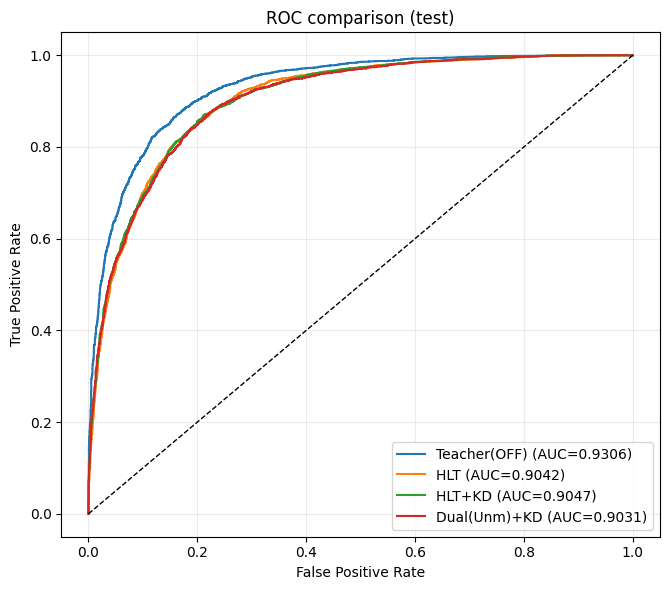

Saved figure: d:\PracticeTagging\unmerge\unmerger_o\runs\OrderedUnmerger_obj_only\figs\auc_bar.png


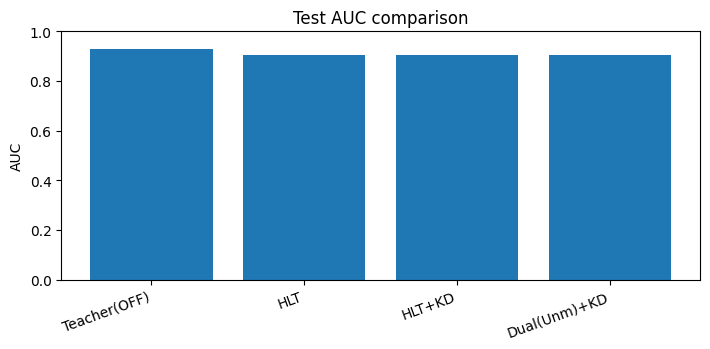

In [ ]:
# Downstream models: teacher / HLT baseline / HLT KD / Dual(unmerge) KD

BSt = 512
train_tag_ds = tool.JetTaggerDataset(
    train_idx,
    y=y,
    w=w,
    off_feat_std=off_feat_std,
    off_mask=off_mask,
    hlt_feat_std=hlt_feat_std,
    hlt_mask=hlt_mask,
    unm_feat_std=unm_feat_std_all,
    unm_mask=unm_mask_all,
)
val_tag_ds = tool.JetTaggerDataset(
    val_idx,
    y=y,
    w=w,
    off_feat_std=off_feat_std,
    off_mask=off_mask,
    hlt_feat_std=hlt_feat_std,
    hlt_mask=hlt_mask,
    unm_feat_std=unm_feat_std_all,
    unm_mask=unm_mask_all,
)
test_tag_ds = tool.JetTaggerDataset(
    test_idx,
    y=y,
    w=w,
    off_feat_std=off_feat_std,
    off_mask=off_mask,
    hlt_feat_std=hlt_feat_std,
    hlt_mask=hlt_mask,
    unm_feat_std=unm_feat_std_all,
    unm_mask=unm_mask_all,
)

train_tag_loader = DataLoader(train_tag_ds, batch_size=BSt, shuffle=True, drop_last=True)
val_tag_loader = DataLoader(val_tag_ds, batch_size=BSt)
test_tag_loader = DataLoader(test_tag_ds, batch_size=BSt)

TAGGER_CFG = {
    'input_dim': int(CONFIG['model']['input_dim']),
    'embed_dim': 128,
    'num_heads': 8,
    'num_layers': 4,
    'ff_dim': 512,
    'dropout': 0.1,
}
TRAIN_CFG = {
    'epochs': 30,
    'lr': 5e-4,
    'weight_decay': 1e-5,
    'patience': 5,
    'grad_clip': 1.0,
}
KD_CFG = {
    'temperature': 3.0,
    'alpha_kd': 0.5,
    'alpha_attn': 0.0,
}

ckpt_dir = CONFIG['io']['ckpt_dir']
load_ckpt = CONFIG['io'].get('load_ckpt', None)
ckpt_teacher = os.path.join(ckpt_dir, 'tagger_teacher_off.pt')
ckpt_hlt = os.path.join(ckpt_dir, 'tagger_hlt_baseline.pt')
ckpt_hlt_kd = os.path.join(ckpt_dir, 'tagger_hlt_kd.pt')
ckpt_dual_kd = os.path.join(ckpt_dir, 'tagger_dual_unm_kd.pt')

# 1) Teacher (offline)
teacher = TokenTagger(**TAGGER_CFG).to(device)
if os.path.exists(ckpt_teacher) and load_ckpt is not None:
    print('Loading teacher:', ckpt_teacher)
    tool.load_checkpoint(teacher, ckpt_teacher, map_location=device)
else:
    best, _ = tool.train_teacher(teacher, train_tag_loader, val_tag_loader, device, **TRAIN_CFG)
    tool.save_checkpoint(teacher, ckpt_teacher, extra={'best_val_auc': float(best)})

# 2) HLT baseline
hlt_base = TokenTagger(**TAGGER_CFG).to(device)
if os.path.exists(ckpt_hlt) and load_ckpt is not None:
    print('Loading HLT baseline:', ckpt_hlt)
    tool.load_checkpoint(hlt_base, ckpt_hlt, map_location=device)
else:
    best, _ = tool.train_hlt_baseline(hlt_base, train_tag_loader, val_tag_loader, device, **TRAIN_CFG)
    tool.save_checkpoint(hlt_base, ckpt_hlt, extra={'best_val_auc': float(best)})

# 3) HLT KD student
hlt_kd = TokenTagger(**TAGGER_CFG).to(device)
if os.path.exists(ckpt_hlt_kd) and load_ckpt is not None:
    print('Loading HLT KD:', ckpt_hlt_kd)
    tool.load_checkpoint(hlt_kd, ckpt_hlt_kd, map_location=device)
else:
    best, _ = tool.train_hlt_kd(
        hlt_kd,
        teacher,
        train_tag_loader,
        val_tag_loader,
        device,
        **TRAIN_CFG,
        **KD_CFG,
    )
    tool.save_checkpoint(hlt_kd, ckpt_hlt_kd, extra={'best_val_auc': float(best)})

# 4) Dual-view (HLT + Unmerged) KD student
dual_kd = DualViewTagger(**TAGGER_CFG, fuse_heads=8).to(device)
if os.path.exists(ckpt_dual_kd) and load_ckpt is not None:
    print('Loading Dual KD:', ckpt_dual_kd)
    tool.load_checkpoint(dual_kd, ckpt_dual_kd, map_location=device)
else:
    best, _ = tool.train_dual_student_kd(
        dual_kd,
        teacher,
        train_tag_loader,
        val_tag_loader,
        device,
        **TRAIN_CFG,
        **KD_CFG,
    )
    tool.save_checkpoint(dual_kd, ckpt_dual_kd, extra={'best_val_auc': float(best)})

# Evaluate AUC on TEST
auc_teacher = tool.eval_auc_logits(teacher, test_tag_loader, device, kind='teacher')
auc_hlt = tool.eval_auc_logits(hlt_base, test_tag_loader, device, kind='hlt')
auc_hlt_kd = tool.eval_auc_logits(hlt_kd, test_tag_loader, device, kind='hlt')
auc_dual_kd = tool.eval_auc_logits(dual_kd, test_tag_loader, device, kind='dual')

print('TEST AUCs:')
print('  Teacher(OFF):', auc_teacher)
print('  HLT baseline:', auc_hlt)
print('  HLT + KD    :', auc_hlt_kd)
print('  Dual(Unm)+KD:', auc_dual_kd)

# Plot ROC curves (one figure)
curves = {}
from sklearn.metrics import roc_curve  # local import

p, y_true = tool.collect_probs_logits(teacher, test_tag_loader, device, kind='teacher')
fpr, tpr, _ = roc_curve(y_true, p)
curves['Teacher(OFF)'] = (fpr, tpr, auc_teacher)

p, y_true = tool.collect_probs_logits(hlt_base, test_tag_loader, device, kind='hlt')
fpr, tpr, _ = roc_curve(y_true, p)
curves['HLT'] = (fpr, tpr, auc_hlt)

p, y_true = tool.collect_probs_logits(hlt_kd, test_tag_loader, device, kind='hlt')
fpr, tpr, _ = roc_curve(y_true, p)
curves['HLT+KD'] = (fpr, tpr, auc_hlt_kd)

p, y_true = tool.collect_probs_logits(dual_kd, test_tag_loader, device, kind='dual')
fpr, tpr, _ = roc_curve(y_true, p)
curves['Dual(Unm)+KD'] = (fpr, tpr, auc_dual_kd)

fig_path = os.path.join(CONFIG['io']['fig_dir'], 'roc_comparison.png')
tool.plot_roc_curves(curves, title='ROC comparison (test) | TPR vs log FPR', save_path=fig_path, dpi=160, log_fpr=True)

# AUC bar chart
names = ['Teacher(OFF)', 'HLT', 'HLT+KD', 'Dual(Unm)+KD']
aucs = [auc_teacher, auc_hlt, auc_hlt_kd, auc_dual_kd]
plt.figure(figsize=(7.2, 3.6))
plt.bar(names, aucs)
plt.ylim(0.0, 1.0)
plt.ylabel('AUC')
plt.xticks(rotation=20, ha='right')
plt.title('Test AUC comparison')
plt.tight_layout()
bar_path = os.path.join(CONFIG['io']['fig_dir'], 'auc_bar.png')
plt.savefig(bar_path, dpi=160, bbox_inches='tight')
print('Saved figure:', bar_path)
plt.show()
